In [1]:
from dataclasses import dataclass

from mesa import Agent, Model

from mesa.space import SingleGrid

from mesa.datacollection import DataCollector

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128

import numpy as np
import pandas as pd

In [2]:
#Clase para representar los estados de las paredes de una celda
@dataclass
class CellWalls:
    #Estado de las 4 paredes de una celda: 2 = intacta, 1 = dañada, 0 = destruida/inexistente
    up: int = 0
    down: int = 0
    left: int = 0
    right: int = 0

#Clase para representar el estado de las posibles puertas de una celda (ocupan el mismo borde que una pared)
@dataclass
class CellDoors:
    #Estado de las 4 puertas de una celda: 2 = cerrada, 1 = abierta, 0 = destruida/inexistente
    up: int = 0
    down: int = 0
    left: int = 0
    right: int = 0

#Clase especializda para crear y modificar estado de paredes y puertas (entorno)
class EnvironmentManager(Model):
    #Guardar dirección opuesta para sincronizar daños con la celda que comparte la pared/puerta
    OPPOSITE_DIRECTIONS = {"up": "down", "down": "up", "left": "right", "right": "left"}
    #Desplazamiento necesario (drow, dcolumn) hacia la celda vecina según la ubicación de la pared en la celda
    NEIGHBOR_OFFSETS = {"up": (-1, 0), "down": (1, 0), "left": (0, -1), "right": (0, 1)}

    def __init__(self, columns, rows, wall_layout=None, door_layout=None):
        super().__init__()

        self.columns = columns
        self.rows = rows
        self._total_damage_markers = 0 #contador de marcadores de daño
        self.walls = [ #usar clase de paredes creada para cada casilla del grid
            [CellWalls() for _ in range(columns)]
            for _ in range(rows)
        ]
        self.doors = [ #usar clase de puertas creada para cada casilla del grid
            [CellDoors() for _ in range(columns)]
            for _ in range(rows)
        ]

        if wall_layout: #añadir paredes iniciales
            self.load_wall_layout(wall_layout)

        if door_layout: #añadir puertas iniciales (siempre inician cerradas)
            self.load_door_layout(door_layout)

    def load_wall_layout(self, wall_layout):
        #Desempaquetar paredes iniciales. Cada entrada es un diccionario {row, column, direction, state}
        for wall in wall_layout:
            self._set_wall(
                wall["row"],
                wall["column"],
                wall["direction"],
                wall["state"]
            )

    #Establecer pared del layout
    def _set_wall(self, row, column, direction, value):
        setattr(self.walls[row][column], direction, value)

        #obtener celda con la que comparte pared
        drow, dcolumn = self.NEIGHBOR_OFFSETS[direction]
        nrow, ncolumn = row + drow, column + dcolumn
        if 0 <= nrow < self.rows and 0 <= ncolumn < self.columns:
            opposite = self.OPPOSITE_DIRECTIONS[direction]
            setattr(self.walls[nrow][ncolumn], opposite, value) #sincronizar pared con esa celda

    def load_door_layout(self, door_layout):
        #Desempaquetar puertas iniciales. Cada entrada es un diccionario {row, column, direction, state}
        for door in door_layout:
            self._set_door(
                door["row"],
                door["column"],
                door["direction"],
                door["state"]
            )

    #Establecer puerta del layout (reemplaza cualquier pared que existiera en ese mismo borde)
    def _set_door(self, row, column, direction, value):
        setattr(self.walls[row][column], direction, 0) #el borde deja de ser una pared
        setattr(self.doors[row][column], direction, value)

        #obtener celda con la que comparte la puerta
        drow, dcolumn = self.NEIGHBOR_OFFSETS[direction]
        nrow, ncolumn = row + drow, column + dcolumn
        if 0 <= nrow < self.rows and 0 <= ncolumn < self.columns:
            opposite = self.OPPOSITE_DIRECTIONS[direction]
            setattr(self.walls[nrow][ncolumn], opposite, 0)
            setattr(self.doors[nrow][ncolumn], opposite, value) #sincronizar puerta con esa celda

    @property #crear atributo a partir de función. Para número de marcadores de daño
    def total_damage_markers(self):
        return self._total_damage_markers

    #Dañar pared (sincronizando las 2 celdas que la comparten)
    def damage_wall(self, row: int, column: int, direction: str):
        if direction not in self.NEIGHBOR_OFFSETS:
            raise ValueError(f"Dirección inválida: {direction}")

        cell = self.walls[row][column]
        current_value = getattr(cell, direction)
        if current_value > 0: #la pared aún existe
            setattr(cell, direction, current_value - 1) #añadirle 1 marcador de daño
            self._total_damage_markers += 1 #sumar un marcador de daño al contador total

        #obtener celda con la que comparte pared para añadirle el daño también
        drow, dcolumn = self.NEIGHBOR_OFFSETS[direction]
        nrow, ncolumn = row + drow, column + dcolumn
        if 0 <= nrow < self.rows and 0 <= ncolumn < self.columns:
            opposite = self.OPPOSITE_DIRECTIONS[direction]
            neighbor = self.walls[nrow][ncolumn]
            neighbor_value = getattr(neighbor, opposite)
            if neighbor_value > 0:
                setattr(neighbor, opposite, neighbor_value - 1)

    #Abrir/cerrar una puerta. Un bombero en la celda gasta 1 PA para llamar a este método (se gestiona fuera de esta clase)
    def toggle_door(self, row: int, column: int, direction: str):
        current_value = getattr(self.doors[row][column], direction)
        if current_value == 0:
            raise ValueError("No existe una puerta en esa posición")

        new_value = 1 if current_value == 2 else 2 #alternar entre abierta (1) y cerrada (2)
        setattr(self.doors[row][column], direction, new_value)

        #sincronizar el nuevo estado con la celda vecina que comparte la puerta
        drow, dcolumn = self.NEIGHBOR_OFFSETS[direction]
        nrow, ncolumn = row + drow, column + dcolumn
        if 0 <= nrow < self.rows and 0 <= ncolumn < self.columns:
            opposite = self.OPPOSITE_DIRECTIONS[direction]
            setattr(self.doors[nrow][ncolumn], opposite, new_value)

    #Destruir una puerta (por una explosión u onda de choque, no genera marcadores de daño)
    def destroy_door(self, row: int, column: int, direction: str):
        setattr(self.doors[row][column], direction, 0) #el marco destruido se trata como pared destruida/abierta

        drow, dcolumn = self.NEIGHBOR_OFFSETS[direction]
        nrow, ncolumn = row + drow, column + dcolumn
        if 0 <= nrow < self.rows and 0 <= ncolumn < self.columns:
            opposite = self.OPPOSITE_DIRECTIONS[direction]
            setattr(self.doors[nrow][ncolumn], opposite, 0)

    #Función para que el modelo o los agentes obtengan si hay una pared, puerta abierta o cerrada
    def getBarrier(self, row, column, direction):
        if getattr(self.walls[row][column], direction) > 0:
            return "wall"
        elif getattr(self.doors[row][column], direction) == 2:
            return "closedDoor"
        elif getattr(self.doors[row] [column], direction) == 1:
            return "openedDoor"
        else:
            return None


In [3]:
#Paredes iniciales del tablero (2 = intacta), coordenadas de acuerdo a la gráfica
initial_wall_layout = (
    #Paredes exteriores
    [{"row": 0, "column": column, "direction": "down", "state": 2} for column in range(1, 9)] +
    [{"row": row, "column": 0, "direction": "right", "state": 2} for row in range(1, 7)] +
    [{"row": 6, "column": column, "direction": "down", "state": 2} for column in range(1, 9)] +
    [{"row": row, "column": 8, "direction": "right", "state": 2} for row in range(1, 7)] +

    #Paredes interiores
    [{"row": 4, "column": column, "direction": "down", "state": 2} for column in range(1, 9)] +
    [{"row": row, "column": 7, "direction": "right", "state": 2} for row in range(5, 7)] +
    [
        {"row": 3, "column": 6, "direction": "right", "state": 2},
        {"row": 4, "column": 2, "direction": "right", "state": 2},
        {"row": 4, "column": 6, "direction": "right", "state": 2},
        {"row": 3, "column": 2, "direction": "right", "state": 2},
        {"row": 5, "column": 5, "direction": "right", "state": 2},
        {"row": 6, "column": 5, "direction": "right", "state": 2},
    ] +
    [{"row": row, "column": 3, "direction": "right", "state": 2} for row in range(1, 3)] +
    [{"row": row, "column": 5, "direction": "right", "state": 2} for row in range(1, 3)] +
    [{"row": 3, "column": column, "direction": "up", "state": 2} for column in range(3, 9)]
)

#Puertas iniciales del tablero (siempre inician cerradas, state = 2), ubicadas sobre bordes que antes eran pared
initial_door_layout = (
    #Puertas intermedias (comunican habitaciones interiores entre sí)
    [
        {"row": 1, "column": 3, "direction": "right", "state": 2},
        {"row": 2, "column": 5, "direction": "right", "state": 2},
        {"row": 3, "column": 2, "direction": "right", "state": 2},
        {"row": 4, "column": 4, "direction": "down", "state": 2},
        {"row": 4, "column": 6, "direction": "right", "state": 2},
        {"row": 3, "column": 8, "direction": "up", "state": 2},
        {"row": 6, "column": 5, "direction": "right", "state": 2},
        {"row": 6, "column": 7, "direction": "right", "state": 2},
    ] +
    #Puertas de entrada (comunican el interior del edificio con el exterior)
    [
        {"row": 0, "column": 6, "direction": "down", "state": 2},
        {"row": 3, "column": 1, "direction": "left", "state": 2},
        {"row": 6, "column": 3, "direction": "down", "state": 2},
        {"row": 4, "column": 8, "direction": "right", "state": 2},
    ]
)


In [4]:
#class FirefighterAgent(Agent):

In [5]:
class FireRescueModel(Model):
    def __init__(self, columns, rows, num_players):
        super().__init__()

        self.columns = columns
        self.rows = rows

        # Grid para los bomberos (agentes)
        self.FigthersGrid = SingleGrid(columns, rows, torus=False)

        # Matriz para los objetos de tipo fuego/humo
        self.fireCells = np.zeros((rows, columns), dtype=int)

        # Manejador de paredes y puertas, cargado con las coordenadas iniciales del tablero
        self.environment = EnvironmentManager(columns, rows, initial_wall_layout, initial_door_layout)

        # Coordenadas de fuegos existentes al inicio del juego (row, column)
        initialFires = [
            (2, 2),
            (2, 3),
            (3, 2),
            (3, 3),
            (3, 4),
            (3, 5),
            (4, 4),
            (5, 6),
            (5, 7),
            (6, 6)
        ]

        for row, column in initialFires:
            self.fireCells[row, column] = 2  # 2 equivale a fuego


    def advanceFire(self):
        # Simula el tiro de dados para ir a la casilla
        # donde debe avanzar el fuego
        row = self.random.randrange(self.rows)
        column = self.random.randrange(self.columns)

        if self.fireCells[row, column] == 0:
            # No hay ni fuego ni humo en la casilla
            if self.check_adjacentFires(row, column):
                self.fireCells[row, column] = 2
                # Si hay fuegos adyacentes se añade fuego
            else:
                self.fireCells[row, column] = 1
                # Si no hay fuegos adyacentes se añade humo

        elif self.fireCells[row, column] == 1:
            # Hay humo en la casilla, se añade fuego
            self.fireCells[row, column] = 2

        elif self.fireCells[row, column] == 2:
            # Hay fuego en la casilla, se genera una explosión
            self.explosion(row, column)


    def check_adjacentFires(self, row, column):
        # Coordenadas adyacentes dentro de la matriz
        neighbors = [
            (row - 1, column, "up"),
            (row + 1, column, "down"),
            (row, column - 1, "left"),
            (row, column + 1, "right")
        ]

        for neighbor_row, neighbor_column, direction in neighbors:
            # Revisa que la coordenada esté dentro de la matriz
            if (0 <= neighbor_row < self.rows and 0 <= neighbor_column < self.columns):
                barrier = self.environment.getBarrier(row, column, direction)
                #revisar que haya fuego en la coordenada Y que no haya una pared o puerta cerrada
                if self.fireCells[neighbor_row, neighbor_column] == 2 and (barrier == None or barrier == "openedDoor"):
                    return True

        return False


    def explosion(self, row, column):
        # Coordenadas adyacentes de la celda de la explosión dentro de la matriz
        neighbors = [
            (row - 1, column, "up"),
            (row + 1, column, "down"),
            (row, column - 1, "left"),
            (row, column + 1, "right")
        ]
        for neighbor_row, neighbor_column, direction in neighbors:
            barrier = self.environment.getBarrier(row, column, direction)
            #Hay pared: la explosión la daña y no continúa
            if barrier == "wall":
                self.environment.damage_wall(row, column, direction)
            #Hay puerta cerrada: la destruye y no continúa
            elif barrier == "closedDoor":
                self.environment.destroy_door(row, column, direction)
            else:
                #Puerta abierta: la explosión la destruye, pero sí continúa
                if barrier == "openedDoor":
                    self.environment.destroy_door(row, column, direction)
                if (0 <= neighbor_row < self.rows and
                    0 <= neighbor_column < self.columns):
                    #Hay celda vacía: se convierte en fuego
                    if self.fireCells[neighbor_row, neighbor_column] == 0:
                        self.fireCells[neighbor_row, neighbor_column] = 2
                    #Hay humo: se convierte en fuego
                    elif self.fireCells[neighbor_row, neighbor_column] == 1:
                        self.fireCells[neighbor_row, neighbor_column] = 2
                    #Hay fuego: comienza shockwave en esa dirección
                    elif self.fireCells[neighbor_row, neighbor_column] == 2:
                        self.shockwave(
                            neighbor_row,
                            neighbor_column,
                            direction
                        )

    def shockwave(self, row, column, direction):
        #Obtener drow y dcolumn para seguir avanzando en esa dirección
        drow, dcolumn = self.environment.NEIGHBOR_OFFSETS[direction]
        current_row = row
        current_column = column
        #Mientras siga encontrando fuego (sin encontrar un return)
        while True:
            #Revisar si hay barrera entre la celda actual y la siguiente
            barrier = self.environment.getBarrier(
                current_row,
                current_column,
                direction
            )
            #Hay pared: la explosión la daña y no continúa
            if barrier == "wall":
                self.environment.damage_wall(
                    current_row,
                    current_column,
                    direction
                )
                return
            #Hay puerta cerrada: la destruye y no continúa
            elif barrier == "closedDoor":
                self.environment.destroy_door(
                    current_row,
                    current_column,
                    direction
                )
                return
            #Puerta abierta: la explosión la destruye, pero sí continúa
            elif barrier == "openedDoor":
                self.environment.destroy_door(
                    current_row,
                    current_column,
                    direction
                )
            #Obtener la siguiente celda en esa misma dirección
            next_row = current_row + drow
            next_column = current_column + dcolumn
            #Ya salió de la matriz (fin)
            if not (0 <= next_row < self.rows and
                    0 <= next_column < self.columns):
                return
            #Hay espacio vacío: se convierte en fuego y termina
            if self.fireCells[next_row, next_column] == 0:
                self.fireCells[next_row, next_column] = 2
                return
            #Hay humo: se convierte en fuego y termina
            elif self.fireCells[next_row, next_column] == 1:
                self.fireCells[next_row, next_column] = 2
                return
            #Hay fuego, la onda sigue avanzando
            elif self.fireCells[next_row, next_column] == 2:
                current_row = next_row
                current_column = next_column

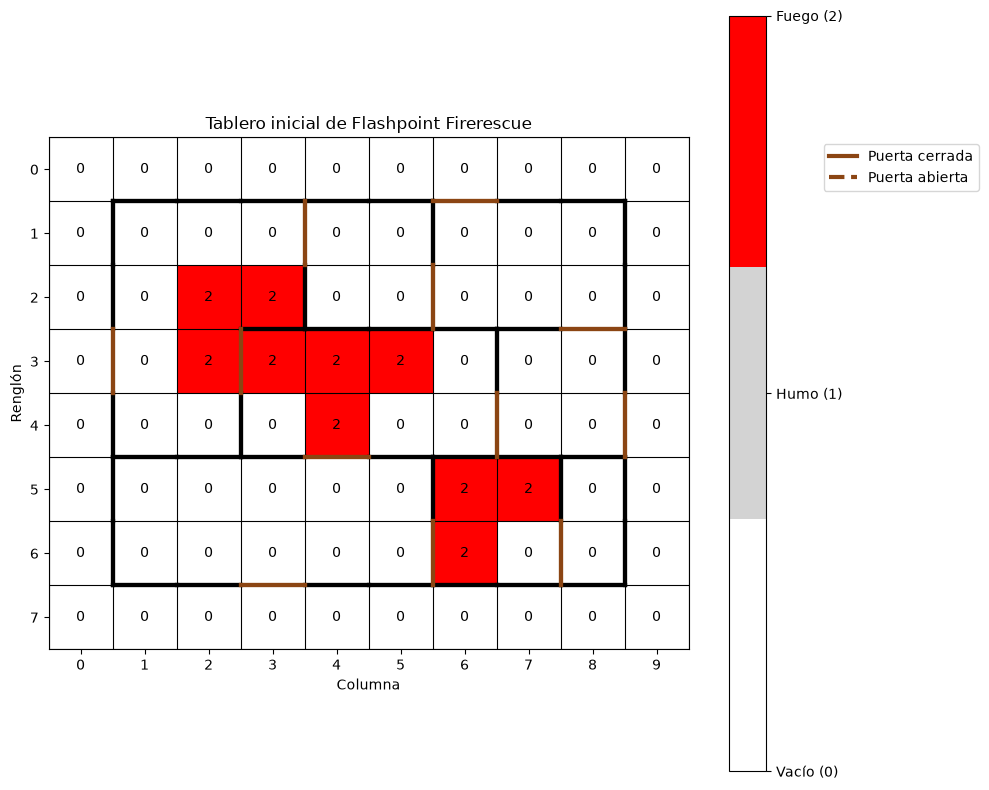

In [6]:
# Configuración inicial de dimensiones y modelo
columns = 10
rows = 8
num_players = 6

model = FireRescueModel(columns, rows, num_players)

# Muestra la matriz de los fuegos, igual al tablero inicial del juego
fig, axis = plt.subplots(figsize=(10, 8))

image = axis.imshow(
    model.fireCells,
    origin="upper",
    cmap=matplotlib.colors.ListedColormap(["white", "lightgray", "red"]),
    vmin=0,
    vmax=2
)

axis.set_title("Tablero inicial de Flashpoint Firerescue")
axis.set_xlabel("Columna")
axis.set_ylabel("Renglón")

axis.set_xticks(range(columns))
axis.set_yticks(range(rows))

axis.set_xticks(np.arange(-0.5, columns, 1), minor=True)
axis.set_yticks(np.arange(-0.5, rows, 1), minor=True)

axis.grid(which="minor", color="black", linewidth=0.8)
axis.tick_params(which="minor", bottom=False, left=False)

# Renderizado de números dentro de las celdas
for row in range(rows):
    for column in range(columns):
        axis.text(
            column,
            row,
            str(model.fireCells[row, column]),
            ha="center",
            va="center"
        )

# Color usado para marcar todas las puertas sobre el tablero
DOOR_COLOR = "saddlebrown"

# Dibuja las paredes intactas (valor 2) y las puertas sobre los bordes de cada celda
for row in range(model.environment.rows):
    for column in range(model.environment.columns):
        cell = model.environment.walls[row][column]
        door = model.environment.doors[row][column] #estado de las puertas de esta celda (0=no hay, 1=abierta, 2=cerrada)
        x_left, x_right = column - 0.5, column + 0.5
        y_top, y_bottom = row - 0.5, row + 0.5

        if cell.up == 2:
            axis.plot([x_left, x_right], [y_top, y_top], color="black", linewidth=3, zorder=3)
        if cell.down == 2:
            axis.plot([x_left, x_right], [y_bottom, y_bottom], color="black", linewidth=3, zorder=3)
        if cell.left == 2:
            axis.plot([x_left, x_left], [y_top, y_bottom], color="black", linewidth=3, zorder=3)
        if cell.right == 2:
            axis.plot([x_right, x_right], [y_top, y_bottom], color="black", linewidth=3, zorder=3)

        # Las puertas se dibujan en DOOR_COLOR; línea sólida = cerrada, punteada = abierta
        if door.up > 0:
            axis.plot([x_left, x_right], [y_top, y_top], color=DOOR_COLOR, linewidth=3, zorder=4, linestyle="-" if door.up == 2 else "--")
        if door.down > 0:
            axis.plot([x_left, x_right], [y_bottom, y_bottom], color=DOOR_COLOR, linewidth=3, zorder=4, linestyle="-" if door.down == 2 else "--")
        if door.left > 0:
            axis.plot([x_left, x_left], [y_top, y_bottom], color=DOOR_COLOR, linewidth=3, zorder=4, linestyle="-" if door.left == 2 else "--")
        if door.right > 0:
            axis.plot([x_right, x_right], [y_top, y_bottom], color=DOOR_COLOR, linewidth=3, zorder=4, linestyle="-" if door.right == 2 else "--")

colorbar = fig.colorbar(image, ax=axis, ticks=[0, 1, 2])
colorbar.ax.set_yticklabels(["Vacío (0)", "Humo (1)", "Fuego (2)"])

# Leyenda para distinguir el estado (abierta/cerrada) de las puertas dibujadas
door_legend_handles = [
    matplotlib.lines.Line2D([0], [0], color=DOOR_COLOR, linewidth=3, linestyle="-", label="Puerta cerrada"),
    matplotlib.lines.Line2D([0], [0], color=DOOR_COLOR, linewidth=3, linestyle="--", label="Puerta abierta"),
]
axis.legend(handles=door_legend_handles, loc="upper left", bbox_to_anchor=(1.2, 1))

fig.tight_layout()
plt.show()
